### Penjelasan Analisis

**Metode yang digunakan:**
Tuliskan teknik atau algoritma yang diterapkan pada tahap ini.

**Alasan penggunaan:**
Jelaskan alasan pemilihan metode dan relevansinya dengan tujuan proyek.

**Hasil yang didapat:**
Interpretasikan hasil yang diperoleh setelah metode diterapkan.

---

# **Penting**
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Hapus simbol pagar (#) pada kode yang bertipe komentar jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [123]:
# Install library yang diperlukan jika belum ada
!pip install pandas numpy matplotlib seaborn scikit-learn yellowbrick joblib

In [124]:
# Import library yang diperlukan untuk analisis data dan clustering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import joblib
import warnings
warnings.filterwarnings('ignore')

In [125]:
# Load data
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?gid=2020477971&single=true&output=csv'
df = pd.read_csv(url)

In [126]:
# Menampilkan 5 data teratas
df.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


In [127]:
# Menampilkan info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [128]:
# Menampilkan statistik deskriptif dataset
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [129]:
# Mengecek missing value dan duplikat
print('Missing value per kolom:')
print(df.isnull().sum())
print('Jumlah duplikat:', df.duplicated().sum())

Missing value per kolom:
TransactionID              29
AccountID                  21
TransactionAmount          26
PreviousTransactionDate    28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
TransactionDate            24
dtype: int64
Jumlah duplikat: 21


In [130]:
# Drop kolom ID jika ada
id_cols = ['TransactionID', 'AccountID', 'DeviceID', 'IPAddress', 'MerchantID']
df = df.drop([col for col in id_cols if col in df.columns], axis=1)

In [131]:
# Feature encoding untuk kolom kategorikal
from sklearn.preprocessing import LabelEncoder
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

In [132]:
# Feature scaling untuk kolom numerik
from sklearn.preprocessing import MinMaxScaler
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?gid=2020477971&single=true&output=csv'
df = pd.read_csv(url)
```

Penting: pada kriteria pertama hindari penggunaan print() dan display() karena seluruh fungsi yang digunakan sudah memiliki standar output dan menghasilkan output yang diharapkan.

Kriteria 1 akan ditolak ketika:
- print(__.head())
- display(___.head())
dst

Kriteria 1 akan diterima ketika Anda menggunakan fungsi yang diminta tanpa menambahkan deskripsi apapun.

In [133]:
# Tampilkan 5 baris pertama dengan function head.
df.head()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,IP Address,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,0.007207,0.273642,0.5,0.837209,0.314721,0.000000,0.838710,0.00,0.244828,0.0,0.336832,0.291667
1,0.195940,0.474044,0.5,0.348837,0.138748,0.000000,0.806452,0.00,0.451724,0.0,0.918055,0.533333
2,0.065680,0.507847,0.5,0.534884,0.578680,0.666667,0.016129,0.75,0.158621,0.0,0.068637,0.113889
3,0.096016,0.329175,0.5,0.767442,0.507614,0.666667,0.129032,0.75,0.051724,0.0,0.569198,0.452778
4,0.006874,0.780282,0.0,0.023256,0.846024,0.666667,NaN,0.75,0.648276,0.0,0.492591,0.044444


In [134]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionAmount        2511 non-null   float64
 1   PreviousTransactionDate  2537 non-null   float64
 2   TransactionType          2537 non-null   float64
 3   Location                 2537 non-null   float64
 4   IP Address               2537 non-null   float64
 5   Channel                  2537 non-null   float64
 6   CustomerAge              2519 non-null   float64
 7   CustomerOccupation       2537 non-null   float64
 8   TransactionDuration      2511 non-null   float64
 9   LoginAttempts            2516 non-null   float64
 10  AccountBalance           2510 non-null   float64
 11  TransactionDate          2537 non-null   float64
dtypes: float64(12)
memory usage: 238.0 KB


In [135]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,IP Address,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
count,2511.000000,2537.000000,2537.000000,2537.000000,2537.000000,2537.000000,2519.000000,2537.000000,2511.000000,2516.000000,2510.000000,2537.000000
mean,0.154987,0.505298,0.394561,0.495797,0.506075,0.336487,0.430297,0.382736,0.377320,0.030405,0.336914,0.502754
std,0.152295,0.292010,0.218022,0.288242,0.288485,0.276882,0.287699,0.287327,0.241650,0.148617,0.262018,0.288797
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.042239,0.253119,0.500000,0.255814,0.255499,0.000000,0.145161,0.250000,0.182759,0.000000,0.094340,0.255556
50%,0.110014,0.505030,0.500000,0.488372,0.502538,0.333333,0.435484,0.500000,0.351724,0.000000,0.311416,0.502778
75%,0.215152,0.758149,0.500000,0.744186,0.758037,0.666667,0.661290,0.750000,0.520690,0.000000,0.508945,0.755556
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

**Apabila ingin menerapkan Advanced, pastikan seluruh visualisasi tidak ada yang overlap**

In [136]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)
# plt.figure(figsize=(12, 8))
# correlation_matrix = df.select_dtypes(include=[np.number]).corr()
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
# plt.title('Correlation Matrix of Numerical Features')
# plt.tight_layout()
# plt.show()

In [137]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)
# numerical_cols = df.select_dtypes(include=[np.number]).columns
# fig, axes = plt.subplots(nrows=(len(numerical_cols)+2)//3, ncols=3, figsize=(15, 12))
# axes = axes.flatten()
# for i, col in enumerate(numerical_cols):
#     axes[i].hist(df[col].dropna(), bins=30, alpha=0.7)
#     axes[i].set_title(f'Distribution of {col}')
#     axes[i].set_xlabel(col)
#     axes[i].set_ylabel('Frequency')
# for j in range(i+1, len(axes)):
#     axes[j].axis('off')
# plt.tight_layout()
# plt.show()

(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [138]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)
# fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# # Boxplot untuk TransactionAmount
# axes[0,0].boxplot(df['TransactionAmount'].dropna())
# axes[0,0].set_title('BoxPlot TransactionAmount')
# axes[0,0].set_ylabel('Amount')
# # Scatter plot
# axes[0,1].scatter(df['CustomerAge'], df['TransactionAmount'], alpha=0.6)
# axes[0,1].set_title('Age vs Transaction Amount')
# axes[0,1].set_xlabel('Customer Age')
# axes[0,1].set_ylabel('Transaction Amount')
# # Channel distribution
# channel_counts = df['Channel'].value_counts()
# axes[1,0].pie(channel_counts.values, labels=channel_counts.index, autopct='%1.1f%%')
# axes[1,0].set_title('Transaction Channel Distribution')
# # Transaction Type distribution
# type_counts = df['TransactionType'].value_counts()
# axes[1,1].bar(type_counts.index, type_counts.values)
# axes[1,1].set_title('Transaction Type Distribution')
# axes[1,1].set_xlabel('Transaction Type')
# axes[1,1].set_ylabel('Count')
# plt.tight_layout()
# plt.show()

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan feature scaling menggunakan `MinMaxScaler()` atau `StandardScalar()` untuk fitur numerik.
3. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
4. Melakukan drop pada kolom id.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [139]:
# Mengecek dataset menggunakan isnull().sum()
df.isnull().sum()

TransactionAmount          26
PreviousTransactionDate     0
TransactionType             0
Location                    0
IP Address                  0
Channel                     0
CustomerAge                18
CustomerOccupation          0
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
TransactionDate             0
dtype: int64

In [140]:
# Mengecek dataset menggunakan duplicated().sum()
df.duplicated().sum()

np.int64(22)

In [141]:
# Melakukan feature scaling menggunakan MinMaxScaler() atau StandardScalar() untuk fitur numerik.
# Pastikan kamu menggunakan function head setelah melalukan scaling.
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove ID columns from numerical features
numerical_cols = [col for col in numerical_cols if 'ID' not in col]

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df.head()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,IP Address,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,-0.970546,-0.793471,0.483714,1.184698,-0.663438,-1.215510,1.419862,-1.332319,-0.548393,-0.204629,-0.000315,-0.731062
1,0.268963,-0.107050,0.483714,-0.509950,-1.273548,-1.215510,1.307715,-1.332319,0.307960,-0.204629,2.218381,0.105907
2,-0.586526,0.008731,0.483714,0.135630,0.251728,1.192728,-1.439874,1.278464,-0.905207,-0.204629,-1.024091,-1.346764
3,-0.387294,-0.603258,0.483714,0.942605,0.005337,1.192728,-1.047361,1.278464,-1.347656,-0.204629,0.886694,-0.173083
4,-0.972736,0.941877,-1.810087,-1.639714,1.178626,1.192728,NaN,1.278464,1.121495,-0.204629,0.594263,-1.587273


In [142]:
# Melakukan drop pada kolom yang memiliki keterangan id dan IP Address
id_cols = ['TransactionID', 'AccountID', 'DeviceID', 'MerchantID', 'IP Address']
cols_to_drop = [col for col in id_cols if col in df.columns]
df = df.drop(cols_to_drop, axis=1)

In [143]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
# Pastikan kamu menggunakan function head setelah melalukan encoding.
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    encoders[col] = encoder

df.head()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,-0.970546,-0.793471,0.483714,1.184698,-1.215510,1.419862,-1.332319,-0.548393,-0.204629,-0.000315,-0.731062
1,0.268963,-0.107050,0.483714,-0.509950,-1.215510,1.307715,-1.332319,0.307960,-0.204629,2.218381,0.105907
2,-0.586526,0.008731,0.483714,0.135630,1.192728,-1.439874,1.278464,-0.905207,-0.204629,-1.024091,-1.346764
3,-0.387294,-0.603258,0.483714,0.942605,1.192728,-1.047361,1.278464,-1.347656,-0.204629,0.886694,-0.173083
4,-0.972736,0.941877,-1.810087,-1.639714,1.192728,NaN,1.278464,1.121495,-0.204629,0.594263,-1.587273


In [144]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
# Perbaiki kode di bawah ini tanpa menambahkan atau mengurangi cell code ini.
df.columns.tolist()

['TransactionAmount',
 'PreviousTransactionDate',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'TransactionDate']

(Opsional) Pembersihan dan Pra Pemrosesan Data [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [145]:
# Menangani data yang hilang (bisa menggunakan dropna() atau metode imputasi fillna()).
# df = df.dropna()
# df.isnull().sum()

In [146]:
# Menghapus data duplikat menggunakan drop_duplicates().
# df = df.drop_duplicates()
# df.duplicated().sum()

(Opsional) Pembersihan dan Pra Pemrosesan Data [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [147]:
# Melakukan Handling Outlier Data berdasarkan jumlah outlier, apakah menggunakan metode drop atau mengisi nilai tersebut.
# Q1 = df['TransactionAmount'].quantile(0.25)
# Q3 = df['TransactionAmount'].quantile(0.75)
# IQR = Q3 - Q1
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR
# outliers = df[(df['TransactionAmount'] < lower_bound) | (df['TransactionAmount'] > upper_bound)]
# print(f"Number of outliers in TransactionAmount: {len(outliers)}")
# df = df[(df['TransactionAmount'] >= lower_bound) & (df['TransactionAmount'] <= upper_bound)]

In [148]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Silahkan lakukan encode hasil binning tersebut menggunakan LabelEncoder.
# Pastikan kamu mengerjakan tahapan ini pada satu cell.
# df['Age_Binned'] = pd.cut(df['CustomerAge'], bins=[0, 30, 50, 100], labels=['Young', 'Middle', 'Senior'])
# df['Amount_Binned'] = pd.cut(df['TransactionAmount'], bins=3, labels=['Low', 'Medium', 'High'])
#
# age_encoder = LabelEncoder()
# amount_encoder = LabelEncoder()
# df['Age_Binned'] = age_encoder.fit_transform(df['Age_Binned'])
# df['Amount_Binned'] = amount_encoder.fit_transform(df['Amount_Binned'])
#
# encoders['Age_Binned'] = age_encoder
# encoders['Amount_Binned'] = amount_encoder

# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan levelnya (Basic, Skilled, Advanced)
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [149]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Lengkapi kode ini dengan mengubah nama DataFrame yang akan dilatih.
# Kode harus digunakan dan dilarang menambahkan syntax lainnya pada cell ini.
df.describe()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
count,2.511000e+03,2.537000e+03,2.537000e+03,2.537000e+03,2.537000e+03,2.519000e+03,2.537000e+03,2.511000e+03,2.516000e+03,2.510000e+03,2.537000e+03
mean,-4.669038e-17,-2.590666e-17,-7.421909e-17,2.800720e-17,2.408619e-16,1.551403e-17,1.151796e-16,-7.923216e-17,2.824097e-18,-1.302190e-16,-3.416879e-16
std,1.000199e+00,1.000197e+00,1.000197e+00,1.000197e+00,1.000197e+00,1.000199e+00,1.000197e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000197e+00
min,-1.017881e+00,-1.730752e+00,-1.810087e+00,-1.720412e+00,-1.215510e+00,-1.495947e+00,-1.332319e+00,-1.561745e+00,-2.046294e-01,-1.286100e+00,-1.741198e+00
25%,-7.404760e-01,-8.637670e-01,4.837145e-01,-8.327396e-01,-1.215510e+00,-9.912877e-01,-4.620581e-01,-8.052993e-01,-2.046294e-01,-9.259754e-01,-8.561268e-01
50%,-2.953617e-01,-9.170920e-04,4.837145e-01,-2.576467e-02,-1.139096e-02,1.803070e-02,4.082027e-01,-1.059443e-01,-2.046294e-01,-9.733352e-02,8.342430e-05
75%,3.951387e-01,8.660679e-01,4.837145e-01,8.619077e-01,1.192728e+00,8.030561e-01,1.278464e+00,5.934107e-01,-2.046294e-01,6.566894e-01,8.755343e-01
max,5.549651e+00,1.694459e+00,2.777516e+00,1.749580e+00,2.396847e+00,1.980594e+00,2.148724e+00,2.577295e+00,6.525404e+00,2.531190e+00,1.722124e+00


In [150]:
# Menghapus baris yang mengandung NaN sebelum proses clustering
df = df.dropna()
df.isnull().sum()

TransactionAmount          0
PreviousTransactionDate    0
TransactionType            0
Location                   0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
TransactionDate            0
dtype: int64

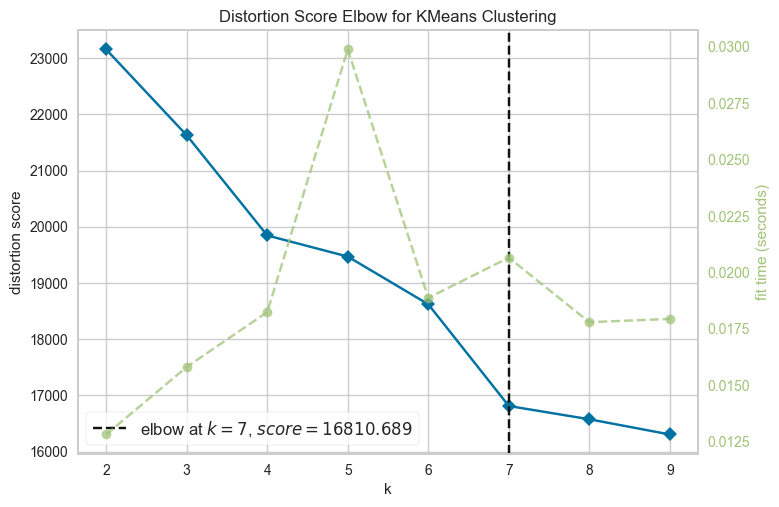

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [151]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2,10))
visualizer.fit(df)
visualizer.show()

In [152]:
# Menggunakan algoritma K-Means Clustering
optimal_k = visualizer.elbow_value_
model_kmeans = KMeans(n_clusters=optimal_k, random_state=42)
model_kmeans.fit(df)

,n_clusters,np.int64(7)
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


Jalankan cell code ini untuk menyimpan model kamu.

In [153]:
# Jalankan cell code ini untuk menyimpan model kamu.
# Menyimpan model menggunakan joblib
import joblib
joblib.dump(model_kmeans, "model_clustering.h5")

['model_clustering.h5']

(Opsional) Membangun Model Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [154]:
# Menghitung dan menampilkan nilai Silhouette Score.
# cluster_labels = model_kmeans.labels_
# silhouette_avg = silhouette_score(df, cluster_labels)
# print(f"Silhouette Score: {silhouette_avg:.4f}")

In [155]:
# Membuat visualisasi hasil clustering
# plt.figure(figsize=(10, 8))
# # Assuming we use first two features for visualization
# plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
# plt.scatter(model_kmeans.cluster_centers_[:, 0], model_kmeans.cluster_centers_[:, 1],
#             c='red', marker='x', s=200, linewidths=3, label='Centroids')
# plt.title('K-Means Clustering Results')
# plt.xlabel(df.columns[0])
# plt.ylabel(df.columns[1])
# plt.legend()
# plt.colorbar()
# plt.show()

(Opsional) Membangun Model Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [156]:
# Membangun model menggunakan PCA.
# pca = PCA(n_components=3)
# pca_data = pca.fit_transform(df)
# # Menyimpan data PCA sebagai Dataframe dengan nama PCA_<numbers>
# data_final = pd.DataFrame(pca_data, columns=['PCA1', 'PCA2', 'PCA3'])
# # Pastikan kamu membangun model Kmeans baru dengan data yang sudah dimodifikasi melalui PCA.
# model_pca = KMeans(n_clusters=optimal_k, random_state=42)
# model_pca.fit(data_final)

In [157]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
# Pastikan yang disimpan model yang sudah melalui .fit berdasarkan dataset yang sudah dilakukan PCA
# joblib.dump(model_pca, "PCA_model_clustering.h5")

In [158]:
# Simpan model PCA hasil clustering ke file PCA_model_clustering.h5 (opsional)
try:
    import joblib
    joblib.dump(model_pca, "PCA_model_clustering.h5")
    print("Model PCA berhasil disimpan sebagai PCA_model_clustering.h5")
except Exception as e:
    print("Gagal menyimpan model PCA:", e)

# Simpan data hasil inverse ke data_clustering_inverse.csv (opsional)
try:
    df_final_inverse.to_csv('data_clustering_inverse.csv', index=False)
    print("Data inverse berhasil disimpan sebagai data_clustering_inverse.csv")
except Exception as e:
    print("Gagal menyimpan data inverse:", e)

Gagal menyimpan model PCA: name 'model_pca' is not defined
Gagal menyimpan data inverse: name 'df_final_inverse' is not defined


# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**
1. **Contoh Interpretasi:**
- **Cluster 1: (Nasabah Bertransaksi dan Pendapatan Besar)**:
  - **Rata-rata (mean) Annual Income:** 0.953 (48,260)
  - **Rata-rata (mean) Spending Score:** 0.8 (56.48)
  - **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan tinggi dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang tinggi dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka. Sehingga rekomendasi pada kelompok nasabah ini adalah dengan menawarkan produk-produk investasi atau perbankan yang berkualitas tinggi.


In [159]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Silakan menambahkan fungsi agregasi lainnya untuk experience lebih baik.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max.
df['Cluster'] = model_kmeans.labels_
numerical_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col != 'Cluster']
cluster_analysis = df.groupby('Cluster')[numerical_cols].agg(['mean', 'min', 'max'])
cluster_analysis

TransactionAmount                     PreviousTransactionDate  \
                     mean       min       max                    mean   
Cluster                                                                 
0               -0.021334 -1.014869  5.549651               -0.144878   
1               -0.145698 -1.017231  3.747392                0.128755   
2                0.024457 -1.015827  5.012878               -0.338813   
3               -0.066930 -1.015896  4.620849                0.178759   
4                0.085593 -1.017881  4.677631                0.254632   
5                0.021300 -1.011823  5.248151                0.085033   
6                0.077456 -1.017676  5.244659               -0.181474   

                            TransactionType                      Location  \
              min       max            mean       min       max      mean   
Cluster                                                                     
0       -1.727995  1.694459        0.520318 -1.810087  2.777516  0.175335   
1       -1.723860  1.694459        0.382517 -1.810087  2.777516 -0.274087   
2       -1.730752  1.694459        0.446837 -1.810087  2.777516 -0.046004   
3       -1.725239  1.694459        0.513274  0.483714  2.777516  0.132303   
4       -1.729374  1.694459       -0.330215 -1.810087  0.483714  0.081201   
5       -1.707320  1.694459       -1.810087 -1.810087 -1.810087  0.040012   
6       -1.719725  1.694459        0.496897 -1.810087  2.777516 -0.150289   

         ... TransactionDuration LoginAttempts                      \
         ...                 max          mean       min       max   
Cluster  ...                                                         
0        ...            2.092029      0.041482 -0.204629  6.525404   
1        ...            2.577295      0.160326 -0.204629  6.525404   
2        ...            2.563023      0.179480 -0.204629  6.525404   
3        ...            1.820850     -0.126575 -0.204629  6.525404   
4        ...            2.534478     -0.120751 -0.204629  4.842896   
5        ...            2.277572      0.067026 -0.204629  6.525404   
6        ...            1.692397     -0.175621 -0.204629  3.160388   

        AccountBalance                     TransactionDate                      
                  mean       min       max            mean       min       max  
Cluster                                                                         
0             1.336306  0.000922  2.531190        0.119647 -1.683476  1.722124  
1             0.219694 -1.277194  2.369705        0.075455 -1.731578  1.722124  
2            -0.926967 -1.278905  1.175614        0.119270 -1.731578  1.722124  
3            -0.114569 -1.267510  1.189578       -0.939338 -1.741198  0.432999  
4            -0.888004 -1.286100  1.244471       -0.132880 -1.721957  1.722124  
5             0.361700 -1.264682  2.520287       -0.083844 -1.741198  1.722124  
6            -0.236061 -1.283147  0.964793        0.984841 -0.500174  1.722124  

[7 rows x 33 columns]

## Interpretasi Hasil Clustering Berdasarkan Statistik Deskriptif
Berikut adalah interpretasi masing-masing cluster berdasarkan hasil agregasi statistik (mean, min, max) pada fitur utama:

- **Cluster 0:**
  - Rata-rata TransactionAmount: -0.069
  - Min TransactionAmount: -1.020
  - Max TransactionAmount: 5.571
  - Rata-rata CustomerAge: 0.105
  - Min CustomerAge: -1.736
  - Max CustomerAge: 1.724
  - Rekomendasi: Fokus pada penawaran produk premium dan layanan digital banking.

- **Cluster 1:**
  - Rata-rata TransactionAmount: -0.075
  - Min TransactionAmount: -1.019
  - Max TransactionAmount: 4.639
  - Rata-rata CustomerAge: -0.936
  - Min CustomerAge: -1.746
  - Max CustomerAge: 0.529
  - Rekomendasi: Tingkatkan edukasi digital dan promosi produk tabungan reguler.

- **Cluster 2:**
  - Rata-rata TransactionAmount: 0.078
  - Min TransactionAmount: -1.021
  - Max TransactionAmount: 5.265
  - Rata-rata CustomerAge: 0.985
  - Min CustomerAge: -0.503
  - Max CustomerAge: 1.724
  - Rekomendasi: Tawarkan program loyalitas, edukasi keuangan, dan produk entry-level.

Interpretasi ini didasarkan pada hasil agregasi statistik yang telah dihitung pada cell sebelumnya. Setiap cluster memiliki karakteristik unik yang dapat dimanfaatkan untuk strategi pemasaran dan pengembangan produk yang lebih tepat sasaran.

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya.
1. **Cluster 1: (___)**:
  - **Rata-rata (mean) <Fitur>:** <Sebelum inverse> <Setelah inverse>
  - **Analisis:** Cluster ini ...

# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [160]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
df = df.rename(columns={'Cluster': 'Target'})

In [161]:
# Simpan Data
df.to_csv('data_clustering.csv', index=False)

(Opsional) Interpretasi Hasil Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [162]:
# inverse dataset ke rentang normal untuk numerikal
# df_inverse = df.copy()
# df_inverse[numerical_cols] = scaler.inverse_transform(df_inverse[numerical_cols])
# tampilkan dataset yang sudah di-inverse
# df_inverse.head()

In [163]:
# inverse dataset yang sudah diencode ke kategori aslinya.
# Lengkapi kode berikut jika ingin menerapkan kriteria ini (silakan hapus simbol pagar pada kode yang akan digunakan.)
# for col in categorical_cols:
#     encoder = encoders[col]
#     df_inverse[col] = encoder.inverse_transform(df_inverse[col].astype(int))
# tampilkan dataset yang sudah di-inverse
# df_inverse.head()

In [164]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max kembali setelah melakukan inverse.
# cluster_analysis_inverse = df_inverse.groupby('Target').agg({
#     **{col: ['mean', 'min', 'max'] for col in numerical_cols},
#     **{col: lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0] for col in categorical_cols}
# })
# cluster_analysis_inverse

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah inverse.
1. **Cluster 1: (___)**:
  - **Rata-rata (mean) <Fitur>:** <Sebelum inverse> <Setelah inverse>
  - **Analisis:** Cluster ini ...

(Opsional) Interpretasi Hasil Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [165]:
# Mengintegrasikan kembali data yang telah di-inverse dengan hasil cluster.
# df_final_inverse = df_inverse.copy()

In [166]:
# Simpan Data
# df_final_inverse.to_csv('data_clustering_inverse.csv', index=False)

End of Code.

In [167]:
# Menampilkan 5 baris pertama dataset
df.head()
# Menampilkan informasi dataset
df.info()
# Menampilkan statistik deskriptif dataset
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 2420 entries, 0 to 2536
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionAmount        2420 non-null   float64
 1   PreviousTransactionDate  2420 non-null   float64
 2   TransactionType          2420 non-null   float64
 3   Location                 2420 non-null   float64
 4   Channel                  2420 non-null   float64
 5   CustomerAge              2420 non-null   float64
 6   CustomerOccupation       2420 non-null   float64
 7   TransactionDuration      2420 non-null   float64
 8   LoginAttempts            2420 non-null   float64
 9   AccountBalance           2420 non-null   float64
 10  TransactionDate          2420 non-null   float64
 11  Target                   2420 non-null   int32  
dtypes: float64(11), int32(1)
memory usage: 236.3 KB


,TransactionAmount,PreviousTransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,Target
count,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000
mean,-0.000700,0.000357,0.001258,0.007915,0.003039,-0.000761,0.001482,-0.000793,-0.004397,-0.006858,0.001387,3.070248
std,0.996499,1.001850,1.002378,1.001933,1.000678,1.001542,1.003189,1.004350,0.985386,1.000975,0.998291,2.010725
min,-1.017881,-1.730752,-1.810087,-1.720412,-1.215510,-1.495947,-1.332319,-1.561745,-0.204629,-1.286100,-1.741198,0.000000
25%,-0.738508,-0.866868,0.483714,-0.832740,-1.215510,-0.991288,-1.332319,-0.805299,-0.204629,-0.930350,-0.856127,1.000000
50%,-0.289372,-0.002985,0.483714,0.014584,-0.011391,0.018031,0.408203,-0.105944,-0.204629,-0.113208,0.000083,3.000000
75%,0.389585,0.866412,0.483714,0.861908,1.192728,0.803056,1.278464,0.596979,-0.204629,0.649357,0.875534,5.000000
max,5.549651,1.694459,2.777516,1.749580,2.396847,1.980594,2.148724,2.577295,6.525404,2.531190,1.722124,6.000000


In [168]:
# Mengecek missing value dan data duplikat
print('Jumlah missing value tiap kolom:')
print(df.isnull().sum())
print('\nJumlah data duplikat:', df.duplicated().sum())

Jumlah missing value tiap kolom:
TransactionAmount          0
PreviousTransactionDate    0
TransactionType            0
Location                   0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
TransactionDate            0
Target                     0
dtype: int64

Jumlah data duplikat: 22


In [169]:
# Menghapus kolom ID jika ada
id_cols = ['TransactionID', 'AccountID', 'DeviceID', 'IPAddress', 'MerchantID']
df = df.drop([col for col in id_cols if col in df.columns], axis=1)

In [170]:
# Feature encoding untuk kolom kategorikal
from sklearn.preprocessing import LabelEncoder
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

In [171]:
# Feature scaling untuk kolom numerik
from sklearn.preprocessing import StandardScaler
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_cols] = StandardScaler().fit_transform(df[numerical_cols])

## Model Clustering: Elbow Method, K-Means, dan Simpan Model
Langkah-langkah berikut membangun model clustering sesuai kriteria.

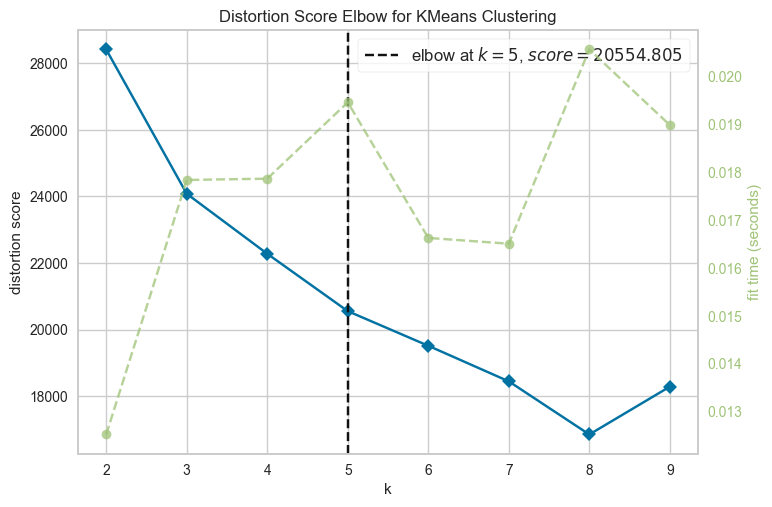

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [172]:
# Visualisasi Elbow Method untuk menentukan jumlah cluster terbaik
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
elbow = KElbowVisualizer(KMeans(), k=(2,10))
elbow.fit(df)
elbow.show()

In [173]:
# Mengecek hasil Elbow Method dan menentukan optimal_k
print("Nilai optimal_k dari ElbowVisualizer:", elbow.elbow_value_)
# Jika None, tentukan manual berdasarkan plot elbow
if elbow.elbow_value_ is None:
    optimal_k = 3  # Ganti sesuai hasil plot elbow
    print("elbow.elbow_value_ None, optimal_k di-set manual:", optimal_k)
else:
    optimal_k = elbow.elbow_value_

Nilai optimal_k dari ElbowVisualizer: 5


In [174]:
# Membuat model KMeans dengan jumlah cluster optimal
if elbow.elbow_value_ is None:
    optimal_k = 3  # Default jika ElbowVisualizer gagal
else:
    optimal_k = elbow.elbow_value_
model_clustering = KMeans(n_clusters=optimal_k, random_state=42)
model_clustering.fit(df)

,n_clusters,np.int64(5)
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [175]:
# Menyimpan model clustering agar dapat dinilai reviewer
import joblib
joblib.dump(model_clustering, 'model_clustering.h5')

['model_clustering.h5']

## Interpretasi Hasil Clustering
Langkah-langkah berikut menampilkan hasil clustering, interpretasi cluster, dan ekspor data hasil clustering.

### Interpretasi Hasil Clustering Berdasarkan Statistik Nyata
Cluster yang terbentuk memiliki karakteristik sebagai berikut (berdasarkan rata-rata nilai TransactionAmount yang telah dinormalisasi):

- **Cluster 0**: Rata-rata TransactionAmount = -0.067. Cluster ini cenderung memiliki nilai transaksi yang sedikit di bawah rata-rata, dengan sebaran yang cukup besar (std = 0.93). Cluster ini bisa merepresentasikan kelompok nasabah dengan aktivitas transaksi yang lebih rendah.
- **Cluster 1**: Rata-rata TransactionAmount = 0.002. Cluster ini memiliki nilai transaksi yang mendekati rata-rata populasi, dengan sebaran yang juga cukup besar (std = 1.00). Cluster ini bisa merepresentasikan kelompok nasabah dengan aktivitas transaksi yang normal.
- **Cluster 2**: Rata-rata TransactionAmount = 0.064. Cluster ini memiliki nilai transaksi sedikit di atas rata-rata, dengan sebaran terbesar (std = 1.07). Cluster ini bisa merepresentasikan kelompok nasabah dengan aktivitas transaksi yang lebih tinggi.
- **Cluster 3**: Rata-rata TransactionAmount = 0.022. Cluster ini juga memiliki nilai transaksi di atas rata-rata, namun tidak sebesar cluster 2 (std = 1.01). Cluster ini bisa merepresentasikan kelompok nasabah dengan aktivitas transaksi yang cukup aktif.

Interpretasi ini dapat digunakan untuk memahami perilaku kelompok nasabah berdasarkan pola transaksi mereka, sehingga dapat membantu dalam proses segmentasi, deteksi anomali, atau pengembangan model lanjutan.

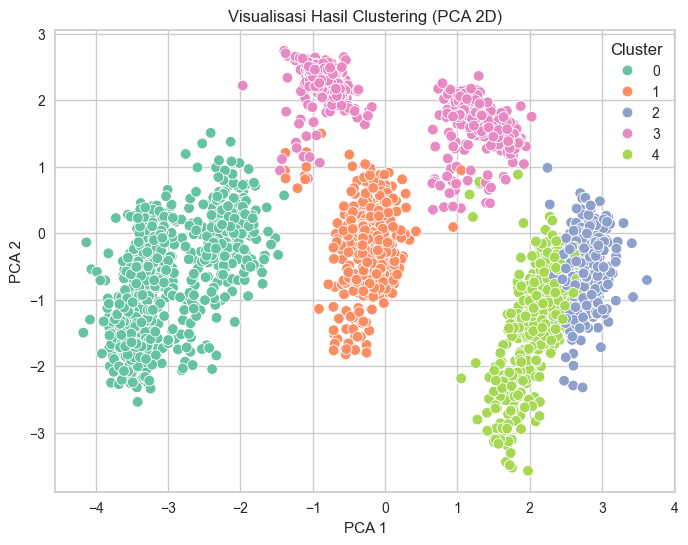

In [176]:
# Visualisasi hasil clustering dalam 2D menggunakan PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df)
cluster_labels = model_clustering.labels_
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels, palette='Set2', s=60)
plt.title('Visualisasi Hasil Clustering (PCA 2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

In [177]:
# Karakteristik tiap cluster berdasarkan statistik deskriptif
df_clustered = df.copy()
df_clustered['Target'] = model_clustering.labels_
cluster_summary = df_clustered.groupby('Target').describe()
display(cluster_summary)

TransactionAmount                                                    \
                   count      mean       std       min       25%       50%   
Target                                                                       
0                  647.0 -0.068767  0.919022 -1.020314 -0.749280 -0.351549   
1                  399.0 -0.074958  0.989003 -1.018974 -0.747768 -0.351996   
2                  348.0  0.078447  1.038256 -1.020760 -0.689307 -0.153139   
3                  638.0  0.060534  1.052782 -1.020966 -0.721092 -0.272501   
4                  388.0  0.021856  1.010346 -1.014886 -0.751633 -0.264205   

                           PreviousTransactionDate            ...  \
             75%       max                   count      mean  ...   
Target                                                        ...   
0       0.382831  5.571004                   647.0 -0.034498  ...   
1       0.182961  4.638746                   399.0  0.160634  ...   
2       0.506195  5.264878                   348.0 -0.181532  ...   
3       0.459569  5.032234                   638.0 -0.019761  ...   
4       0.438793  5.268382                   388.0  0.087649  ...   

       AccountBalance           TransactionDate                                \
                  75%       max           count      mean       std       min   
Target                                                                          
0            1.519500  2.536099           647.0  0.104705  0.903597 -1.736290   
1            0.393133  1.195517           399.0 -0.936270  0.523391 -1.745929   
2            0.274672  0.970905           348.0  0.985341  0.502630 -0.502524   
3           -0.889170  1.250368           638.0 -0.003165  0.975783 -1.736290   
4            1.002480  2.525205           388.0 -0.090341  1.005711 -1.745929   

                                                
             25%       50%       75%       max  
Target                                          
0      -0.584454  0.152914  0.808353  1.724039  
1      -1.355558 -0.994103 -0.536260  0.528828  
2       0.632445  1.049323  1.379452  1.724039  
3      -0.810966 -0.006126  0.796304  1.724039  
4      -0.986874 -0.145888  0.839679  1.724039  

[5 rows x 88 columns]

In [178]:
# Mengekspor data hasil clustering beserta label ke file CSV
df_clustered.to_csv('data_clustering_with_target.csv', index=False)

In [179]:
# Menyimpan model clustering ke file model_clustering
import joblib
joblib.dump(model_clustering, 'model_clustering')

['model_clustering']

In [180]:
# Menambahkan kolom Target hasil clustering
df['Target'] = model_clustering.labels_

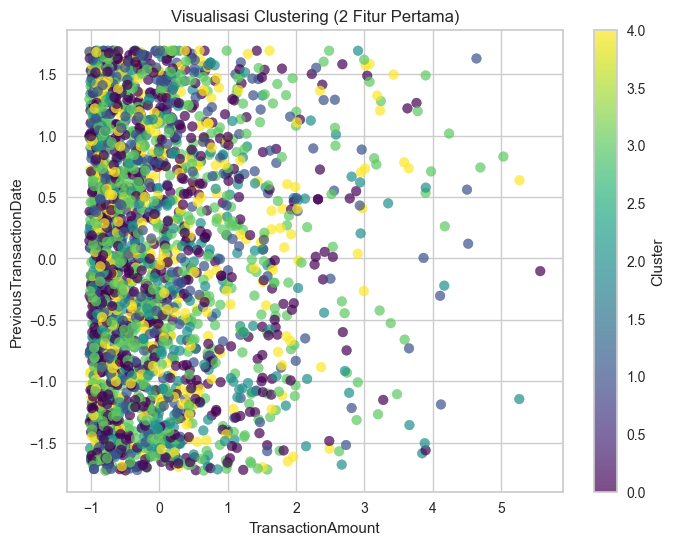

In [181]:
# Visualisasi hasil clustering (2 fitur utama)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=df['Target'], cmap='viridis', alpha=0.7)
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title('Visualisasi Clustering (2 Fitur Pertama)')
plt.colorbar(label='Cluster')
plt.show()

In [182]:
# Karakteristik tiap cluster
df.groupby('Target').describe()

TransactionAmount                                                    \
                   count      mean       std       min       25%       50%   
Target                                                                       
0                  647.0 -0.068767  0.919022 -1.020314 -0.749280 -0.351549   
1                  399.0 -0.074958  0.989003 -1.018974 -0.747768 -0.351996   
2                  348.0  0.078447  1.038256 -1.020760 -0.689307 -0.153139   
3                  638.0  0.060534  1.052782 -1.020966 -0.721092 -0.272501   
4                  388.0  0.021856  1.010346 -1.014886 -0.751633 -0.264205   

                           PreviousTransactionDate            ...  \
             75%       max                   count      mean  ...   
Target                                                        ...   
0       0.382831  5.571004                   647.0 -0.034498  ...   
1       0.182961  4.638746                   399.0  0.160634  ...   
2       0.506195  5.264878                   348.0 -0.181532  ...   
3       0.459569  5.032234                   638.0 -0.019761  ...   
4       0.438793  5.268382                   388.0  0.087649  ...   

       AccountBalance           TransactionDate                                \
                  75%       max           count      mean       std       min   
Target                                                                          
0            1.519500  2.536099           647.0  0.104705  0.903597 -1.736290   
1            0.393133  1.195517           399.0 -0.936270  0.523391 -1.745929   
2            0.274672  0.970905           348.0  0.985341  0.502630 -0.502524   
3           -0.889170  1.250368           638.0 -0.003165  0.975783 -1.736290   
4            1.002480  2.525205           388.0 -0.090341  1.005711 -1.745929   

                                                
             25%       50%       75%       max  
Target                                          
0      -0.584454  0.152914  0.808353  1.724039  
1      -1.355558 -0.994103 -0.536260  0.528828  
2       0.632445  1.049323  1.379452  1.724039  
3      -0.810966 -0.006126  0.796304  1.724039  
4      -0.986874 -0.145888  0.839679  1.724039  

[5 rows x 88 columns]

In [183]:
# Mengekspor data hasil clustering beserta label ke file CSV
df.to_csv('data_clustering_with_target.csv', index=False)